# Heritability within families

Relatives resemble one another because they may share both ancestral DNA and environment. How can family data separate these sources?

## One covariance model

Let $r_{ij}$ measure genetic sharing between relatives $i$ and $j$, and let $c_{ij}$ measure their shared environment. Under an additive model,

$$
\operatorname{Cov}(Y_i,Y_j\mid r_{ij},c_{ij})
=r_{ij}V_A+c_{ij}V_C.
$$

The coefficient of genetic sharing is the additive genetic variance $V_A$. Family designs differ mainly in how they obtain $r_{ij}$.

## Two ways to supply genetic sharing

**Twin and pedigree designs use expected sharing.** Monozygotic twins have $r=1$; dizygotic twins, full siblings, and parent--offspring pairs have $r=1/2$ under the simple additive model. For standardized phenotypes in an ACE model,

$$
\rho_{MZ}=A+C,
\qquad
\rho_{DZ}=\tfrac12 A+C,
$$

which gives Falconer's estimate $h^2\approx2(\rho_{MZ}-\rho_{DZ})$.

**Full-sibling IBD designs measure sharing pair by pair.** Every full-sibling pair has expected sharing $1/2$, but recombination and independent assortment make realized genome-wide IBD sharing $R_i$ vary around that expectation. With

$$
Y_{ij}=\mu+G_{ij}+C_i+E_{ij},
$$

the shared family effect $C_i$ cancels from the sibling difference:

$$
E\!\left[(Y_{i1}-Y_{i2})^2\mid R_i=r\right]
=2V_E+2V_A(1-r).
$$

The prediction is direct: siblings sharing more DNA IBD should be more similar. Twin and pedigree designs compare expected sharing across relationship classes; realized-IBD designs compare measured sharing within one relationship class. Both estimate $V_A$ through the same covariance model.

In [1]:
set.seed(8149)

n_pairs <- 8000
V_A <- 25
V_C <- 4
V_E <- 16
mean_height <- 170

ibd_sharing <- rbeta(n_pairs, shape1 = 50, shape2 = 50)

z1 <- rnorm(n_pairs)
z2 <- rnorm(n_pairs)
genetic_1 <- sqrt(V_A) * z1
genetic_2 <- sqrt(V_A) * (
  ibd_sharing * z1 + sqrt(1 - ibd_sharing^2) * z2
)

shared_environment <- rnorm(n_pairs, 0, sqrt(V_C))
environment_1 <- rnorm(n_pairs, 0, sqrt(V_E))
environment_2 <- rnorm(n_pairs, 0, sqrt(V_E))

phenotype_1 <- mean_height + genetic_1 + shared_environment + environment_1
phenotype_2 <- mean_height + genetic_2 + shared_environment + environment_2

sibling_data <- data.frame(
  ibd_sharing = ibd_sharing,
  unshared_fraction = 1 - ibd_sharing,
  squared_difference = (phenotype_1 - phenotype_2)^2
)

ibd_fit <- lm(squared_difference ~ unshared_fraction, data = sibling_data)
V_A_hat <- unname(coef(ibd_fit)["unshared_fraction"] / 2)
V_E_hat <- unname(coef(ibd_fit)["(Intercept)"] / 2)
V_P_hat <- var(c(phenotype_1, phenotype_2))
h2_hat <- V_A_hat / V_P_hat
h2_expected <- V_A / (V_A + V_C + V_E)

data.frame(
  quantity = c("mean IBD sharing", "V_A", "V_E", "h2"),
  expected = c(0.5, V_A, V_E, h2_expected),
  estimated = c(mean(ibd_sharing), V_A_hat, V_E_hat, h2_hat)
)

quantity,expected,estimated
<chr>,<dbl>,<dbl>
mean IBD sharing,0.5000000,0.5003631
V_A,25.0000000,22.7533047
V_E,16.0000000,17.2249821
h2,0.5555556,0.4978952


slope_with_IBD,slope_after_permutation
<dbl>,<dbl>
45.50661,4.218951


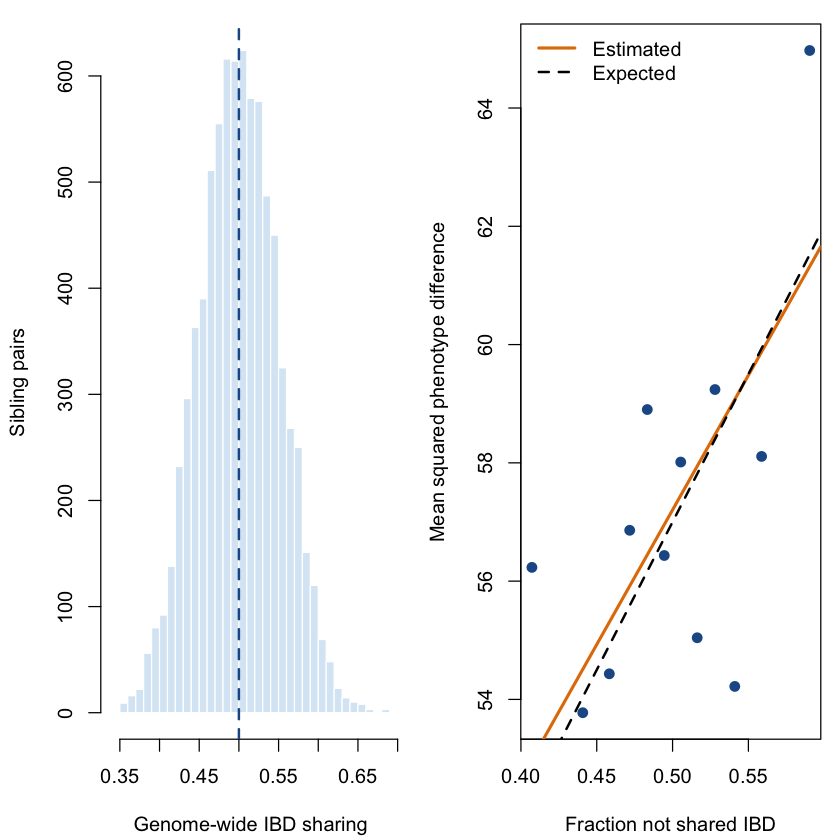

In [2]:
breaks <- unique(quantile(
  sibling_data$unshared_fraction,
  probs = seq(0, 1, length.out = 13)
))
sibling_data$bin <- cut(
  sibling_data$unshared_fraction,
  breaks = breaks,
  include.lowest = TRUE
)

binned_unshared <- aggregate(
  sibling_data$unshared_fraction,
  list(bin = sibling_data$bin),
  mean
)
binned_difference <- aggregate(
  sibling_data$squared_difference,
  list(bin = sibling_data$bin),
  mean
)

shuffled_fit <- lm(
  sibling_data$squared_difference ~ sample(sibling_data$unshared_fraction)
)

old_par <- par(mfrow = c(1, 2), mar = c(4.2, 4.2, 1.0, 0.8))

hist(
  sibling_data$ibd_sharing,
  breaks = 35,
  col = "#D9E8F5",
  border = "white",
  xlab = "Genome-wide IBD sharing",
  ylab = "Sibling pairs",
  main = ""
)
abline(v = 0.5, lty = 2, lwd = 2, col = "#1F5A94")

plot(
  binned_unshared$x,
  binned_difference$x,
  pch = 16,
  cex = 1.2,
  col = "#1F5A94",
  xlab = "Fraction not shared IBD",
  ylab = "Mean squared phenotype difference"
)
abline(ibd_fit, lwd = 2.5, col = "#E17C05")
abline(a = 2 * V_E, b = 2 * V_A, lwd = 2, lty = 2)
legend(
  "topleft",
  legend = c("Estimated", "Expected"),
  col = c("#E17C05", "black"),
  lwd = c(2.5, 2),
  lty = c(1, 2),
  bty = "n"
)

par(old_par)

data.frame(
  slope_with_IBD = unname(coef(ibd_fit)[2]),
  slope_after_permutation = unname(coef(shuffled_fit)[2])
)

stopifnot(abs(mean(ibd_sharing) - 0.5) < 0.01)
stopifnot(abs(V_A_hat - V_A) < 8)
stopifnot(abs(V_E_hat - V_E) < 4)
stopifnot(abs(h2_hat - h2_expected) < 0.12)

## What the example shows

The family environment contributed to phenotypic variance, but it canceled in the within-pair difference. Random meiosis supplied the informative contrast: sibling pairs that shared more of their genomes IBD were more similar on average.

The design does not make every environmental problem disappear. Indirect genetic effects or environments that track the siblings' inherited genotypes can still violate the model. The central gain is narrower: realized IBD sharing varies because of meiosis, while the broad family relationship stays fixed.

## What to remember

- **Concept and intuition.** A pedigree gives expected sharing; meiosis makes realized genome-wide IBD sharing vary among sibling pairs.
- **Insight behind the model.** Regress a within-pair phenotype difference on random variation in IBD sharing. Shared family effects cancel from the difference.
- **Worked example.** The slope against $1-R_i$ recovered $2V_A$, while permuting $R_i$ removed the signal.

## Sources

- Pritchard, *An Owner's Guide to the Human Genome*, Chapter 4.4, Figures 4.50-4.51. [Book page](https://web.stanford.edu/group/pritchardlab/HGbook.html)
- Visscher et al. (2006), *Assumption-Free Estimation of Heritability from Genome-Wide Identity-by-Descent Sharing between Full Siblings*. [Article](https://doi.org/10.1371/journal.pgen.0020041)
- The simulation is an original course example. It uses 8,000 sibling pairs, $R_i\sim\operatorname{Beta}(50,50)$, $V_A=25$, $V_C=4$, $V_E=16$, and seed 8149.